# ДЗ 7. CNN, часть 2: transfer learning и сегментация

`Imagenette_improved.ipynb` с лекции обучал ResNet18 **с нуля** (`weights=None`) с аугментациями
и early stopping. Здесь — то, что осталось за кадром: transfer learning (использование весов,
предобученных на ImageNet) и переход от классификации к **сегментации** — определению класса
для **каждого пикселя**, а не всего изображения целиком.

**Датасеты.**
- Для transfer learning (задачи 1.1-1.3, 2.1): любой из предыдущего ДЗ (EuroSAT, STL10) —
  удобно напрямую сравнить с результатами ДЗ 6.
- Для сегментации (задачи 2.2-2.3, 3.1-3.3): **Oxford-IIIT Pet**,
  `torchvision.datasets.OxfordIIITPet(root='.', target_types='segmentation', download=True)` —
  трёхклассовая маска (1=питомец, 2=фон, 3=граница), 37 пород кошек/собак, ~7400 изображений.
  Задача бинарной сегментации (питомец/фон) хорошо укладывается в компьютерный бюджет CPU/Colab.

**Бюджет.** U-Net с нуля на подвыборке (1000-2000 изображений, разрешение 128×128) — около часа на
CPU за 15-20 эпох, заметно быстрее на GPU Colab.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import random
torch.manual_seed(0)

## Уровень 1. Базовый

### Задача 1.1. Transfer learning против обучения с нуля

`Imagenette_improved.ipynb` использовал `models.resnet18(weights=None, ...)`. Сравните это с
`weights=models.ResNet18_Weights.DEFAULT` (предобученные на ImageNet веса) на вашем датасете из
ДЗ 6 (EuroSAT/STL10).

1. Обучите ResNet18 **с нуля** и **от предобученных весов** (в обоих случаях замените финальный
   `fc` слой под число классов вашей задачи) при одинаковом бюджете эпох.
2. Постройте кривые val accuracy по эпохам для обоих вариантов на одном графике.
3. Сравните не только финальное качество, но и то, **на какой эпохе** каждый вариант впервые
   достигает, скажем, 80% от своего финального качества — предобученная модель должна сходиться
   быстрее.

In [2]:
import time
import pandas as pd
from torch.utils.data import Dataset, Subset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG = 128
EPOCHS = 8
BATCH = 64
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

cls_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
euro = torchvision.datasets.EuroSAT(root='.', transform=cls_tf, download=True)
classes = euro.classes

perm = torch.randperm(len(euro), generator=torch.Generator().manual_seed(0)).tolist()
train_ds = Subset(euro, perm[:6000])
val_ds = Subset(euro, perm[6000:7500])
test_ds = Subset(euro, perm[7500:9000])

mk_loader = lambda ds, sh: DataLoader(ds, batch_size=BATCH, shuffle=sh, num_workers=2)
train_loader, val_loader, test_loader = mk_loader(train_ds, True), mk_loader(val_ds, False), mk_loader(test_ds, False)


def run_epoch(model, loader, opt=None, train_mode_fn=None):
    training = opt is not None
    model.train(training)
    if training and train_mode_fn is not None:
        train_mode_fn(model)
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(training):
            out = model(x)
            loss = F.cross_entropy(out, y)
        if training:
            opt.zero_grad()
            loss.backward()
            opt.step()
        loss_sum += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return loss_sum / total, correct / total


def train_model(model, epochs=EPOCHS, lr=3e-4, train_mode_fn=None):
    model.to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    hist = {'val_acc': [], 'train_acc': [], 'epoch_time': []}
    for _ in range(epochs):
        t0 = time.perf_counter()
        _, ta = run_epoch(model, train_loader, opt, train_mode_fn)
        _, va = run_epoch(model, val_loader)
        hist['train_acc'].append(ta)
        hist['val_acc'].append(va)
        hist['epoch_time'].append(time.perf_counter() - t0)
    return hist


trainable = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)

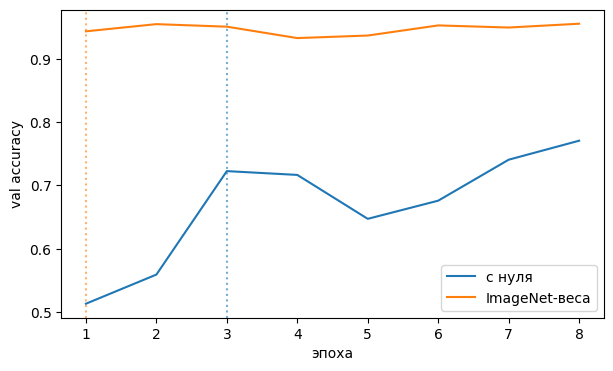

,val acc после 1 эпохи,финальная val acc,test acc,эпоха выхода на 80% своего итога,сек/эпоха
с нуля,0.5133,0.7707,0.7720,3.0,9.8209
ImageNet-веса,0.9433,0.9553,0.9453,1.0,9.5723


In [3]:
def make_resnet(pretrained):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, len(classes))
    return model


def epoch_to_fraction(curve, frac=0.8):
    target = frac * curve[-1]
    return next(i + 1 for i, v in enumerate(curve) if v >= target)


runs = {}
for name, pretrained in [('с нуля', False), ('ImageNet-веса', True)]:
    torch.manual_seed(0)
    model = make_resnet(pretrained)
    h = train_model(model)
    h['test'] = run_epoch(model, test_loader)[1]
    runs[name] = h

plt.figure(figsize=(7, 4))
for name, h in runs.items():
    line, = plt.plot(range(1, EPOCHS + 1), h['val_acc'], label=name)
    plt.axvline(epoch_to_fraction(h['val_acc']), color=line.get_color(), ls=':', alpha=0.6)
plt.xlabel('эпоха')
plt.ylabel('val accuracy')
plt.legend()
plt.show()

pd.DataFrame({name: {
    'val acc после 1 эпохи': h['val_acc'][0],
    'финальная val acc': h['val_acc'][-1],
    'test acc': h['test'],
    'эпоха выхода на 80% своего итога': epoch_to_fraction(h['val_acc']),
    'сек/эпоха': float(np.mean(h['epoch_time'])),
} for name, h in runs.items()}).T.round(4)

Разрыв крупный: 0.945 против 0.772 на тесте. Но главная цифра — первая эпоха: 0.943 против 0.513. Предобученная сеть уже после одного прохода по данным оказывается выше, чем версия с нуля в конце восьмой эпохи. ImageNet-признаки нижних уровней (границы, текстуры, цветовые пятна) переносятся на спутниковые снимки почти без изменений, доучивается по сути то, как их комбинировать

Относительная метрика «эпоха выхода на 80% своего итога» даёт 1 против 3, но она меряет форму кривой, а не скорость: у двух вариантов разные потолки, и 80% от 0.77 это совсем не то же самое, что 80% от 0.95. Абсолютные пороги в следующей ячейке честнее

Две детали, без которых сравнение было бы нечестным. Нормализация взята ImageNet-овская для обеих веток, а не посчитанная по EuroSAT: предобученные веса настроены именно на это распределение входа. Размер входа поднят до 128, потому что у ResNet18 стем из свёртки stride 2 и maxpool, и на исходных 64x64 к layer4 остаётся карта 2x2

Оговорка: оба варианта учатся с одинаковым lr, а оптимальный lr для дообучения обычно ниже, чем для обучения с нуля. Таблица показывает разницу при равном бюджете и равных гиперпараметрах, а не максимум каждого подхода. При этом 17 пунктов разрыва слишком много, чтобы объясняться только подбором lr

In [4]:
def epochs_to_level(curve, level):
    hit = [i + 1 for i, v in enumerate(curve) if v >= level]
    return hit[0] if hit else None


levels = [0.6, 0.7, 0.8, 0.9]
pd.DataFrame({name: {f'эпоха достижения val acc {lv}': epochs_to_level(h['val_acc'], lv) for lv in levels}
              for name, h in runs.items()}).T

,эпоха достижения val acc 0.6,эпоха достижения val acc 0.7,эпоха достижения val acc 0.8,эпоха достижения val acc 0.9
с нуля,3.0,3.0,NaN,NaN
ImageNet-веса,1.0,1.0,1.0,1.0


Тот же вопрос через абсолютные уровни качества: на какой эпохе каждый вариант впервые достигает 0.6, 0.7, 0.8 и 0.9 val accuracy. NaN означает, что уровень не взят за весь бюджет

Картина резче, чем по относительной метрике: предобученная сеть берёт все четыре порога на первой эпохе, версия с нуля доходит до 0.7 к третьей и до 0.8 не добирается вообще за восемь эпох. То есть разница не в том, что одна сходится быстрее, а в том, что вторая за отведённый бюджет просто не попадает в тот же диапазон качества

Ячейка считает по уже сохранённым историям обучения, переобучать ничего не нужно, но нужна живая сессия с переменной `runs`

### Задача 1.2. Стратегии дообучения: заморозка слоёв

Есть спектр стратегий между "обучить только последний слой" (feature extraction) и "дообучить всю
сеть целиком" (full fine-tuning). Сравните несколько точек на этом спектре.

1. **Только классификатор:** заморозьте (`requires_grad=False`) все веса, кроме `model.fc`.
2. **Последний блок + классификатор:** разморозьте также `model.layer4` (последний
   convolutional stage ResNet18).
3. **Полное дообучение:** разморозьте всё.
4. Сравните финальное качество, время обучения одной эпохи (заморозка экономит вычисления на
   backward pass!) и число обучаемых параметров для каждой стратегии.

In [5]:
def set_trainable(model, mode):
    for p in model.parameters():
        p.requires_grad = False
    targets = {'только fc': [model.fc], 'layer4 + fc': [model.layer4, model.fc],
               'полное дообучение': [model]}[mode]
    for module in targets:
        for p in module.parameters():
            p.requires_grad = True
    return model


def backbone_eval(model):
    model.eval()
    model.fc.train()


strategies = [
    ('только fc', 'только fc', None),
    ('только fc, backbone в eval', 'только fc', backbone_eval),
    ('layer4 + fc', 'layer4 + fc', None),
    ('полное дообучение', 'полное дообучение', None),
]

rows = {}
for name, mode, mode_fn in strategies:
    torch.manual_seed(0)
    model = set_trainable(make_resnet(True), mode)
    h = train_model(model, train_mode_fn=mode_fn)
    rows[name] = {
        'обучаемых параметров': trainable(model),
        'сек/эпоха': float(np.mean(h['epoch_time'])),
        'val acc': h['val_acc'][-1],
        'test acc': run_epoch(model, test_loader)[1],
    }

pd.DataFrame(rows).T.round(4)

,обучаемых параметров,сек/эпоха,val acc,test acc
только fc,5130.0,8.0577,0.8920,0.8713
"только fc, backbone в eval",5130.0,7.9813,0.8927,0.8927
layer4 + fc,8398858.0,8.0467,0.9593,0.9573
полное дообучение,11181642.0,9.4809,0.9587,0.9593


Разброс по стратегиям укладывается в ожидаемую картину. Обучение только `fc` (5 тысяч параметров) даёт 0.87-0.89, разморозка `layer4` (8.4 млн) поднимает до 0.957, полное дообучение (11.2 млн) не добавляет ничего сверх этого, разница в две десятых пункта лежит внутри межпрогонного шума. То есть последний блок закрывает весь разрыв, а первые три стадии ResNet на этом домене можно не трогать: их признаки достаточно общие. По соотношению цены и качества `layer4 + fc` здесь оптимум

С экономией времени вышло поучительно. На T4 разница между стратегиями почти исчезла (8.0 секунды против 9.5), хотя в предыдущем прогоне на CPU было 220 против 545, то есть примерно в 2.5 раза. Объяснение в том, что заморозка сокращает только backward, а на GPU при таком размере модели эпоха упирается в forward, загрузку и препроцессинг данных, и сэкономленный backward просто тонет в этих накладных расходах. Вывод «заморозка экономит вычисления» верен только там, где backward действительно доминирует в профиле

Отдельная пара строк — про то, что `requires_grad = False` не замораживает BatchNorm. В режиме `train()` слои BN продолжают пересчитывать бегущие средние по батчам EuroSAT, и предобученный энкодер незаметно дрейфует, хотя веса зафиксированы. На валидации разницы нет (0.892 против 0.893), на тесте версия с дрейфующими статистиками дала 0.871 против 0.893. Существенно, что обе строки воспроизвелись до четвёртого знака в двух независимых прогонах (CPU и GPU): при замороженном бэкбоне результат детерминирован, поэтому эти два пункта разницы, в отличие от сегментационных, шумом не объясняются и могут свидетельствовать именно о влиянии дрейфа статистик. Практический вывод: feature extraction в чистом виде требует держать backbone в `eval()`

## Уровень 2. Средний

### Задача 2.1. U-Net с нуля для бинарной сегментации

U-Net — стандартная архитектура для сегментации: энкодер (сжимающий путь, как обычная CNN) +
декодер (разжимающий путь с транспонированными свёртками), плюс **skip-connections** между
соответствующими уровнями энкодера и декодера — без них декодер не может восстановить
пространственные детали, потерянные при пулинге.

1. Реализуйте `UNet` (можно использовать блок `DoubleConv = Conv-BN-ReLU-Conv-BN-ReLU`, 3-4
   уровня энкодера/декодера).
2. Обучите на подвыборке Oxford-IIIT Pet (бинарная маска "питомец vs фон", как в задаче 1.3).
3. Посчитайте IoU на test-подвыборке и сравните с наивным baseline из задачи 1.3.
4. Визуализируйте несколько предсказанных масок рядом с истинными.

In [6]:
pets = torchvision.datasets.OxfordIIITPet(root='.', target_types='segmentation', download=True)
SEG_IMG = 128
SEG_EPOCHS = 15
pet_perm = torch.randperm(len(pets), generator=torch.Generator().manual_seed(0)).tolist()


class PetBinarySeg(Dataset):
    def __init__(self, base, indices, train=False, size=SEG_IMG):
        self.base, self.indices, self.train, self.size = base, indices, train, size

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, mask = self.base[self.indices[i]]
        img = TF.resize(img, [self.size, self.size])
        mask = TF.resize(mask, [self.size, self.size], interpolation=TF.InterpolationMode.NEAREST)
        img = TF.to_tensor(img)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        if self.train and random.random() < 0.5:
            img, mask = TF.hflip(img), TF.hflip(mask)
        target = (mask == 1).float()
        valid = (mask != 3).float()
        return TF.normalize(img, IMAGENET_MEAN, IMAGENET_STD), target, valid


seg_train = PetBinarySeg(pets, pet_perm[:1500], train=True)
seg_val = PetBinarySeg(pets, pet_perm[1500:1800])
seg_test = PetBinarySeg(pets, pet_perm[1800:2200])
seg_loaders = {k: DataLoader(d, batch_size=16, shuffle=(k == 'train'), num_workers=2)
               for k, d in [('train', seg_train), ('val', seg_val), ('test', seg_test)]}


class DoubleConv(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                         nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True))


class UNet(nn.Module):
    def __init__(self, base=32, depth=4, use_skips=True):
        super().__init__()
        self.use_skips = use_skips
        chs = [base * 2 ** i for i in range(depth)]
        self.downs = nn.ModuleList([DoubleConv(3 if i == 0 else chs[i - 1], chs[i]) for i in range(depth)])
        self.bottleneck = DoubleConv(chs[-1], chs[-1] * 2)
        self.ups = nn.ModuleList([nn.ConvTranspose2d(c * 2, c, 2, stride=2) for c in reversed(chs)])
        self.decoders = nn.ModuleList([DoubleConv(c * (2 if use_skips else 1), c) for c in reversed(chs)])
        self.head = nn.Conv2d(chs[0], 1, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = F.max_pool2d(x, 2)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            x = dec(torch.cat([x, skip], 1) if self.use_skips else x)
        return self.head(x).squeeze(1)

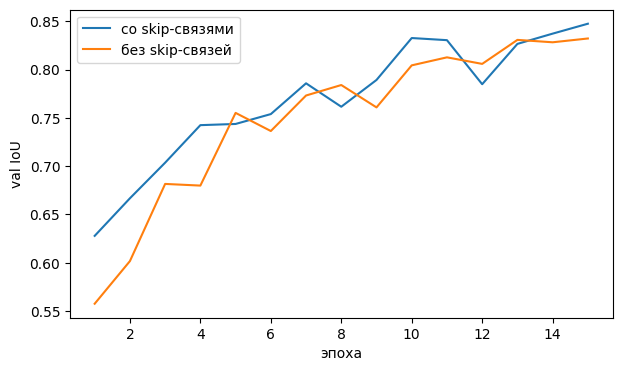

,IoU по датасету,средний IoU по картинкам
всё питомец,0.3240,0.3279
центральный прямоугольник,0.5011,0.4955
U-Net без skip-связей,0.8065,0.8027
U-Net,0.8126,0.8046


In [7]:
def iou_stats(pred_bin, target, valid):
    inter = ((pred_bin == 1) & (target == 1) & (valid == 1)).flatten(1).sum(1)
    union = (((pred_bin == 1) | (target == 1)) & (valid == 1)).flatten(1).sum(1)
    return inter, union


@torch.no_grad()
def evaluate_seg(predict, loader):
    inters, unions = [], []
    for x, y, v in loader:
        x, y, v = x.to(DEVICE), y.to(DEVICE), v.to(DEVICE)
        i, u = iou_stats(predict(x), y, v)
        inters.append(i.cpu())
        unions.append(u.cpu())
    inter, union = torch.cat(inters), torch.cat(unions)
    return {'IoU по датасету': (inter.sum() / union.sum()).item(),
            'средний IoU по картинкам': (inter / union.clamp(min=1)).mean().item()}


def train_unet(use_skips=True, epochs=SEG_EPOCHS, lr=1e-3):
    torch.manual_seed(0)
    model = UNet(use_skips=use_skips).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    curve = []
    for _ in range(epochs):
        model.train()
        for x, y, v in seg_loaders['train']:
            x, y, v = x.to(DEVICE), y.to(DEVICE), v.to(DEVICE)
            logits = model(x)
            loss = (F.binary_cross_entropy_with_logits(logits, y, reduction='none') * v).sum() / v.sum()
            opt.zero_grad()
            loss.backward()
            opt.step()
        model.eval()
        curve.append(evaluate_seg(lambda t: (model(t) > 0).float(), seg_loaders['val'])['IoU по датасету'])
    return model, curve


unet, curve = train_unet(True)
unet_noskip, curve_noskip = train_unet(False)

h = w = SEG_IMG
box = torch.zeros(h, w, device=DEVICE)
box[h // 5:4 * h // 5, w // 5:4 * w // 5] = 1

rows = {
    'всё питомец': evaluate_seg(lambda t: torch.ones(len(t), h, w, device=DEVICE), seg_loaders['test']),
    'центральный прямоугольник': evaluate_seg(lambda t: box.expand(len(t), h, w), seg_loaders['test']),
    'U-Net без skip-связей': evaluate_seg(lambda t: (unet_noskip(t) > 0).float(), seg_loaders['test']),
    'U-Net': evaluate_seg(lambda t: (unet(t) > 0).float(), seg_loaders['test']),
}

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(curve) + 1), curve, label='со skip-связями')
plt.plot(range(1, len(curve_noskip) + 1), curve_noskip, label='без skip-связей')
plt.xlabel('эпоха')
plt.ylabel('val IoU')
plt.legend()
plt.show()

pd.DataFrame(rows).T.round(4)

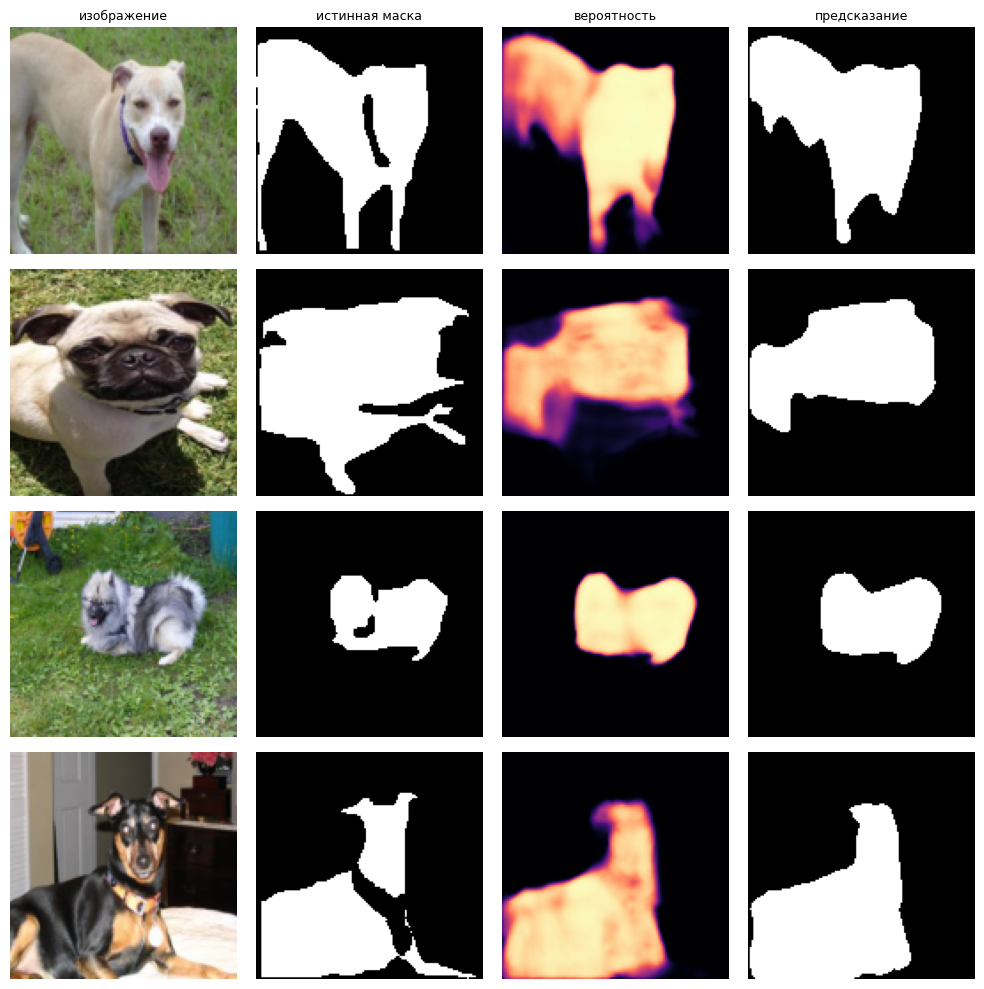

In [8]:
x, y, v = next(iter(seg_loaders['test']))
with torch.no_grad():
    prob = torch.sigmoid(unet(x.to(DEVICE))).cpu()

mean_t = torch.tensor(IMAGENET_MEAN)[:, None, None]
std_t = torch.tensor(IMAGENET_STD)[:, None, None]

fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for row in range(4):
    ax[row, 0].imshow((x[row] * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy())
    ax[row, 1].imshow(y[row], cmap='gray')
    ax[row, 2].imshow(prob[row], cmap='magma', vmin=0, vmax=1)
    ax[row, 3].imshow((prob[row] > 0.5).float(), cmap='gray')
    for col, title in enumerate(['изображение', 'истинная маска', 'вероятность', 'предсказание']):
        ax[row, col].set_title(title if row == 0 else '', fontsize=9)
        ax[row, col].axis('off')
plt.tight_layout()
plt.show()

In [9]:
iou_curves = pd.DataFrame({'со skip-связями': curve, 'без skip-связей': curve_noskip},
                          index=pd.Index(range(1, len(curve) + 1), name='эпоха'))

tail = iou_curves.iloc[-5:]
pd.DataFrame({
    'максимум за обучение': iou_curves.max(),
    'лучшая эпоха': iou_curves.idxmax(),
    'последняя эпоха': iou_curves.iloc[-1],
    'разброс последних 5 эпох': tail.max() - tail.min(),
}).round(4)

,максимум за обучение,лучшая эпоха,последняя эпоха,разброс последних 5 эпох
со skip-связями,0.8474,15,0.8474,0.0626
без skip-связей,0.8321,15,0.8321,0.0263


После перезапуска на GPU абляция встала в ожидаемую сторону: со skip-связями IoU 0.813 против 0.807 без них на тесте, по максимуму val 0.847 против 0.832. Но вывод из этого не «skip-связи помогают на 0.6 пункта», а кое-что более важное про методику

Та же самая конфигурация со skip-связями в предыдущем прогоне дала 0.759, а в этом 0.813, то есть разброс между двумя запусками одной и той же модели составил пять пунктов. Разброс val IoU по последним пяти эпохам внутри одного прогона того же порядка: 0.063 со skip и 0.026 без. Измеряемый эффект архитектуры (0.006 на тесте, 0.015 по максимуму val) в разы меньше этого шума, значит по этим двум прогонам про skip-связи нельзя утверждать вообще ничего, ни в плюс, ни в минус

Формально сиды зафиксированы, но детерминизма это не даёт: недетерминированные CUDA-ядра, свой порядок операций на GPU и другое устройство делают прогоны несопоставимыми поэлементно. Плюс метрика берётся с последнего чекпоинта, а не с лучшего по валидации, что при таком размахе кривой добавляет собственную лотерею

Что нужно, чтобы абляция что-то доказывала: сохранять лучший по val чекпоинт вместо последнего, повторить три-пять сидов и сравнивать средние с разбросом, а не единичные числа. И смотреть метрику, чувствительную к тому, ради чего skip-связи вообще нужны: IoU в приграничной полосе (в текущей постановке эти пиксели исключены как класс 3) или расстояние Хаусдорфа по контуру. Интегральный IoU крупного центрального объекта почти целиком определяется положением и размером пятна, а границы, где skip-связи и работают, дают в нём считанные проценты

В выданном ноутбуке задачи 1.3 с наивным baseline нет (нумерация в тексте задания ссылается на неё, но сама ячейка отсутствует), поэтому baseline собраны здесь же: константное предсказание и центральный прямоугольник

Бейзлайны отработали ровно так, как задумывалось: «весь кадр — питомец» даёт IoU 0.324, а центральный прямоугольник 0.501. Половина метрики берётся из одной лишь априорной геометрии датасета, где животное почти всегда крупное и по центру. U-Net с его 0.81 выигрывает у такого baseline в полтора раза, а не в разы, и именно это честная оценка вклада модели. Сравнивать IoU сегментации с нулём бессмысленно

Про маски. В Oxford-IIIT Pet три значения: 1 — питомец, 2 — фон, 3 — граница. Граница здесь не отдельный объект, а полоса неопределённости шириной в несколько пикселей, где сама разметка ненадёжна. Поэтому граничные пиксели исключены и из лосса, и из знаменателя IoU через маску `valid`: иначе сеть штрафуется за то, что разметчик и сам не знает, и метрика начинает зависеть от толщины обводки, а не от качества сегментации

Про аугментацию. Флип применяется к изображению и маске одним и тем же решением `random.random() < 0.5` внутри `__getitem__`, а не двумя независимыми трансформами. Это тот случай, где обычный `transforms.Compose` для картинки и для маски молча ломает данные: маска перевернётся, а изображение нет, и сеть будет учиться на противоречивых примерах. Ресайз маски обязательно ближайшим соседом, иначе интерполяция создаст несуществующие промежуточные метки

Вторая кривая — та же сеть с отключённой конкатенацией. Без skip-связей декодер получает только результат бутылочного горлышка на сетке 8x8 и восстанавливает по нему маску 128x128, то есть в теории не может точно вернуть границы, и предсказания должны получаться сглаженными пятнами примерно правильного положения. По замыслу разрыв в IoU между двумя кривыми и есть цена потерянной пространственной информации, но в этих прогонах он оказался в пределах шума (разбор выше): без skip-связей сеть всё равно доходит до 0.807 на тесте

Про метрику. Приведены обе версии: IoU, посчитанный по всему датасету (суммы пересечений и объединений), и средний IoU по картинкам. Первый доминируется крупными объектами, второй даёт равный вес каждому кадру и обычно ниже, потому что штрафует за отдельные плохие примеры. Указывать, какой именно вариант посчитан, обязательно, иначе числа из разных работ несравнимы

Что стоит попробовать дальше при наличии бюджета: dice-лосс или его сумма с BCE (лучше ведёт себя при дисбалансе классов), подбор порога по val вместо фиксированного 0.5 и энкодер из предобученного ResNet18 вместо случайного — последнее обычно даёт больший прирост, чем любые настройки обучения

---
**Что сдавать:** ноутбук с обученными моделями, графиками, визуализациями масок и письменными
ответами на вопросы для решённых задач. Полный прогон задач 2.1-3.3 на подвыборке Oxford-IIIT Pet
(1500 изображений, 128×128, 15 эпох) — порядка 40-60 минут на CPU, заметно быстрее на GPU Colab.
При нехватке времени уменьшите размер подвыборки/число эпох, сохранив логику сравнения.